<!-- Google Fonts -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #fff; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 10px; 
        font-size: 36px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        🌪️ Flood Prediction 🌩️
    </h1>
</div>


# 📂 Overview

**Background**

The **Playground Series – Season 4, Episode 5** competition on Kaggle provides a **synthetic flood-risk dataset** built from a blend of natural, ecological, and human-induced factors.
The dataset was **synthetically generated using data simulation techniques** inspired by real-world patterns, ensuring realistic relationships between features while anonymizing and transforming the raw data for open use.

This competition offers an excellent opportunity to practice **regression modeling**, **feature preprocessing**, and **model evaluation** within an environmental risk-assessment context.

> 💡 It is particularly suitable for end-to-end machine-learning practice on tabular data — including EDA, feature engineering, model tuning, and ensemble learning.

**Goal of the Project**

The main objective is to **build a regression model to predict the probability of flooding — `FloodProbability`**, based on environmental, infrastructural, and socio-economic features.

Participants are expected to explore data preprocessing, feature selection, and model optimization techniques to achieve strong generalization on unseen data.

**Key Features**

| Feature                             | Description                                                      |
| ----------------------------------- | ---------------------------------------------------------------- |
| **MonsoonIntensity**                | Intensity of monsoon and regional rainfall                       |
| **TopographyDrainage**              | Terrain elevation and natural drainage capacity                  |
| **RiverManagement**                 | Effectiveness of riverbank and dredging management               |
| **Deforestation**                   | Level of forest loss and vegetation removal                      |
| **Urbanization**                    | Degree of urban expansion and surface concretization             |
| **ClimateChange**                   | Impact of long-term climate change patterns                      |
| **DamsQuality**                     | Quality and maintenance of dams or reservoirs                    |
| **Siltation**                       | Sedimentation level in rivers and water bodies                   |
| **AgriculturalPractices**           | Farming methods and land-use practices                           |
| **Encroachments**                   | Degree of riverbank or channel encroachment                      |
| **IneffectiveDisasterPreparedness** | Inefficiency in disaster-response systems                        |
| **DrainageSystems**                 | Quality of urban drainage and sewer infrastructure               |
| **CoastalVulnerability**            | Coastal sensitivity to storms, tides, and surges                 |
| **Landslides**                      | Frequency or likelihood of landslides                            |
| **Watersheds**                      | Condition and structure of watershed basins                      |
| **DeterioratingInfrastructure**     | Degradation level of public infrastructure                       |
| **PopulationScore**                 | Population density or regional population score                  |
| **WetlandLoss**                     | Degree of natural wetland loss                                   |
| **InadequatePlanning**              | Poor or insufficient urban and regional planning                 |
| **PoliticalFactors**                | Local governance, coordination, and policy factors               |
| **FloodProbability**                | 🎯 **Target variable** — Probability of flood occurrence (0 → 1) |

**Files Provided**

* `train.csv`: Training dataset containing all features and the target variable
* `test.csv`: Test dataset without the target column
* `sample_submission.csv`: Template for the submission format

(Source: [Kaggle Competition Page](https://www.kaggle.com/competitions/playground-series-s4e5/overview))

**Project Objective**

This notebook aims to demonstrate a complete **machine learning workflow** for flood-risk prediction:

* **Exploratory Data Analysis (EDA):**

  * Examine data distribution, missing values, and outliers
  * Explore correlations between natural, urban, and social factors and `FloodProbability`

* **Feature Engineering:**

  * Normalize or scale numerical features
  * Encode categorical variables
  * Create interaction or aggregate features to capture non-linear relationships

* **Modeling & Evaluation:**

  * Experiment with multiple regression algorithms such as **RandomForestRegressor**, **XGBoost**, **LightGBM**, **CatBoost**, **Ridge / Lasso Regression**
  * Implement **k-fold cross-validation** for robust evaluation
  * Compare and fine-tune model performance via hyperparameter optimization

* **Prediction Strategy:**

  * Generate predictions for `FloodProbability` on the test dataset
  * Prepare submission files following the provided sample format

**Evaluation Metric**

The competition uses the **R² score (Coefficient of Determination)** as the evaluation metric.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Import Libraries</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Import Libraries
    </h1>
</div>

In [1]:
# Core data manipulation libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# Statistical functions
from scipy.stats import skew

# Display utilities for Jupyter notebooks
from IPython.display import display

# Machine learning preprocessing and modeling
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 500) # To display all the columns of dataframe
pd.set_option("max_colwidth", None) # To set the width of the column to maximum

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Load Data</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Load Data
    </h1>
</div>


In [2]:
# Load the datasets
# train.csv: Features and target labels
# test.csv: Features only

df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

# Verify shapes
print("Train Data Shape:", df_train.shape)
print("\nTest Data Shape:", df_test.shape)

Train Data Shape: (1117957, 22)

Test Data Shape: (745305, 21)


In [3]:
# Display few rows of each dataset
print("Train Data Preview:")
display(df_train.head())

print("\nTest Data Preview:")
display(df_test.head())

Train Data Preview:


,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,IneffectiveDisasterPreparedness,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,0,5,8,5,8,6,4,4,3,3,4,2,5,3,3,5,4,7,5,7,3,0.445
1,1,6,7,4,4,8,8,3,5,4,6,9,7,2,0,3,5,3,3,4,3,0.450
2,2,6,5,6,7,3,7,1,5,4,5,6,7,3,7,5,6,8,2,3,3,0.530
3,3,3,4,6,5,4,8,4,7,6,8,5,2,4,7,4,4,6,5,7,5,0.535
4,4,5,3,2,6,4,4,3,3,3,3,5,2,2,6,6,4,1,2,3,5,0.415



Test Data Preview:


,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,IneffectiveDisasterPreparedness,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors
0,1117957,4,6,3,5,6,7,8,7,8,4,8,5,7,5,6,3,6,4,4,5
1,1117958,4,4,2,9,5,5,4,7,5,4,2,4,7,4,5,1,7,4,4,3
2,1117959,1,3,6,5,7,2,4,6,4,2,7,9,2,5,5,2,3,6,8,3
3,1117960,2,4,4,6,4,5,4,3,4,4,7,8,4,6,7,6,4,2,4,4
4,1117961,6,3,2,4,6,4,5,5,3,7,4,3,2,6,4,6,8,4,5,5


In [4]:
# Replace space to under score.
df_train.columns = df_train.columns.str.strip().str.replace(" ", "_")
df_test.columns = df_test.columns.str.strip().str.replace(" ", "_")

# Display information about the DataFrames
print("Train Data Info:")
df_train.info()

print("\nTest Data Info:")
df_test.info()

Train Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1117957 entries, 0 to 1117956
Data columns (total 22 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   id                               1117957 non-null  int64  
 1   MonsoonIntensity                 1117957 non-null  int64  
 2   TopographyDrainage               1117957 non-null  int64  
 3   RiverManagement                  1117957 non-null  int64  
 4   Deforestation                    1117957 non-null  int64  
 5   Urbanization                     1117957 non-null  int64  
 6   ClimateChange                    1117957 non-null  int64  
 7   DamsQuality                      1117957 non-null  int64  
 8   Siltation                        1117957 non-null  int64  
 9   AgriculturalPractices            1117957 non-null  int64  
 10  Encroachments                    1117957 non-null  int64  
 11  IneffectiveDisasterPreparedness  

## Insights from Initial Data Exploration

**Dataset Size and Structure**

* The **training dataset** contains **1,117,957 samples** and **22 columns**, including the target variable `FloodProbability`.
* The **test dataset** includes **745,305 samples** and **21 columns** (without the target variable), ready for model inference and leaderboard submission.

**Feature Overview**

* Both datasets include a comprehensive set of environmental, infrastructural, and socio-economic attributes contributing to flood risk assessment.
* All features are **numerical**, represented as integer or float scores ranging from approximately **0 to 10**:

  * Example features include `MonsoonIntensity`, `TopographyDrainage`, `RiverManagement`, `Deforestation`, `Urbanization`, `DrainageSystems`, and others.
* The **target variable** `FloodProbability` is a continuous numerical value (float), representing the **probability of flood occurrence (0 → 1)**.
* There are **no categorical features** in this dataset. All predictors are **ordinal numeric scores** that quantify levels of impact or severity.

**Data Consistency and Completeness**

* Data types are consistent: all predictors are numeric (`int64`) and the target is `float64`.
* The column `id` serves purely as a unique identifier for each observation. It does not carry predictive information and can be **excluded from modeling** or **used as an index** for record tracking.

In [5]:
df_train.drop("id", axis=1, inplace=True)
list_test_id = df_test["id"].copy().to_list()
df_test.drop("id", axis=1, inplace=True)

In [6]:
# Check memory before
print("Before conversion:")
print(df_train.info(memory_usage="deep"))

# Identify integer columns (excluding target)
int_cols = df_train.select_dtypes(include=["int64"]).columns.tolist()

# Convert integer columns to int8
df_train[int_cols] = df_train[int_cols].astype("int8")
df_test[int_cols] = df_test[int_cols].astype("int8")

# Check after conversion
print("\nAfter conversion:")
print(df_train.info(memory_usage="deep"))
print(df_test.info(memory_usage="deep"))

Before conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1117957 entries, 0 to 1117956
Data columns (total 21 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   MonsoonIntensity                 1117957 non-null  int64  
 1   TopographyDrainage               1117957 non-null  int64  
 2   RiverManagement                  1117957 non-null  int64  
 3   Deforestation                    1117957 non-null  int64  
 4   Urbanization                     1117957 non-null  int64  
 5   ClimateChange                    1117957 non-null  int64  
 6   DamsQuality                      1117957 non-null  int64  
 7   Siltation                        1117957 non-null  int64  
 8   AgriculturalPractices            1117957 non-null  int64  
 9   Encroachments                    1117957 non-null  int64  
 10  IneffectiveDisasterPreparedness  1117957 non-null  int64  
 11  DrainageSystems                

In [7]:
print("Train Data describe:")
cmap = sns.light_palette("blue", as_cmap=True)
display(df_train[int_cols].describe().T.style.background_gradient(cmap=cmap))

print("\nTest Data describe:")
display(df_test[int_cols].describe().T.style.background_gradient(cmap=cmap))

Train Data describe:


,count,mean,std,min,25%,50%,75%,max
MonsoonIntensity,1117957.000000,4.921450,2.056387,0.000000,3.000000,5.000000,6.000000,16.000000
TopographyDrainage,1117957.000000,4.926671,2.093879,0.000000,3.000000,5.000000,6.000000,18.000000
RiverManagement,1117957.000000,4.955322,2.072186,0.000000,4.000000,5.000000,6.000000,16.000000
Deforestation,1117957.000000,4.942240,2.051689,0.000000,4.000000,5.000000,6.000000,17.000000
Urbanization,1117957.000000,4.942517,2.083391,0.000000,3.000000,5.000000,6.000000,17.000000
ClimateChange,1117957.000000,4.934093,2.057742,0.000000,3.000000,5.000000,6.000000,17.000000
DamsQuality,1117957.000000,4.955878,2.083063,0.000000,4.000000,5.000000,6.000000,16.000000
Siltation,1117957.000000,4.927791,2.065992,0.000000,3.000000,5.000000,6.000000,16.000000
AgriculturalPractices,1117957.000000,4.942619,2.068545,0.000000,3.000000,5.000000,6.000000,16.000000
Encroachments,1117957.000000,4.949230,2.083324,0.000000,4.000000,5.000000,6.000000,18.000000



Test Data describe:


,count,mean,std,min,25%,50%,75%,max
MonsoonIntensity,745305.000000,4.915610,2.056295,0.000000,3.000000,5.000000,6.000000,16.000000
TopographyDrainage,745305.000000,4.930288,2.094117,0.000000,3.000000,5.000000,6.000000,17.000000
RiverManagement,745305.000000,4.960027,2.071722,0.000000,4.000000,5.000000,6.000000,16.000000
Deforestation,745305.000000,4.946084,2.052602,0.000000,4.000000,5.000000,6.000000,17.000000
Urbanization,745305.000000,4.938424,2.081816,0.000000,3.000000,5.000000,6.000000,17.000000
ClimateChange,745305.000000,4.933524,2.059243,0.000000,3.000000,5.000000,6.000000,17.000000
DamsQuality,745305.000000,4.958468,2.089312,0.000000,4.000000,5.000000,6.000000,16.000000
Siltation,745305.000000,4.927651,2.068110,0.000000,3.000000,5.000000,6.000000,16.000000
AgriculturalPractices,745305.000000,4.945308,2.073404,0.000000,3.000000,5.000000,6.000000,16.000000
Encroachments,745305.000000,4.950620,2.081750,0.000000,4.000000,5.000000,6.000000,17.000000


## Descriptive Insights from Dataset Statistics

**Consistency between Train & Test**

* Both datasets have very **similar distributions**, indicating good data consistency.
* No missing or extreme outlier values observed.
* All 21 input features are **numerical**, with values mostly between **0 and ~18**.

**Range and Scale**

* Most features share a **comparable scale (0–18)**, suitable for direct modeling.
* A few features in `test.csv` (e.g., **WetlandLoss**, `max = 22`) extend slightly beyond the training range but still within the `int8` safe limit.
* Scaling or normalization is optional but can improve convergence for linear models.

**Central Tendency**

* Mean and median of all features are around **4.9–5.0**, showing **balanced score distributions**.
* Standard deviations range between **~2.0–2.1**, indicating moderate variability and no dominant feature.

**Data Integrity**

* No categorical or string features detected.
* All variables are clean and ready for regression modeling.

**Summary for Slide:**

> The dataset is fully numeric, balanced, and clean, consistent across train and test, and perfectly suitable for regression modeling using tree-based algorithms like LightGBM or XGBoost.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Quality Checks</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Quality Checks
    </h1>
</div>

## Missing Value

In [8]:
def displayNULL(df, dataset_name=None):
    total_rows = len(df)

    missing_df = df.isnull().sum().reset_index()
    missing_df.columns = ["Feature", "Missing_Count"]
    missing_df = missing_df[missing_df["Missing_Count"] > 0]
    missing_df["Missing_%"] = (missing_df["Missing_Count"] / total_rows * 100).round(2)
    missing_df = missing_df.sort_values(by="Missing_Count", ascending=False).reset_index(drop=True)

    total_missing = missing_df["Missing_Count"].sum()

    print("=" * 40)
    if dataset_name:
        print(f"🔎 Missing Value Summary for: {dataset_name}")
    else:
        print("🔎 Missing Value Summary:")
    print("=" * 40)
    
    if total_missing == 0:
        print(f"✅ No missing values detected in {total_rows:,} rows.")
    else:
        try:
            from tabulate import tabulate
            print(tabulate(missing_df, headers="keys", tablefmt="pretty", showindex=False, colalign=("left", "left", "left")))
        except ImportError:
            print(missing_df.to_string(index=False))
        
        print(f"\n⚠️  Total missing values: {total_missing:,} out of {total_rows:,} rows.")

print("Missing value train dataset: ")
displayNULL(df_train, dataset_name="Train Set")

print("\nMissing value test dataset: ")
displayNULL(df_test, dataset_name="Test Set")

Missing value train dataset: 
🔎 Missing Value Summary for: Train Set
✅ No missing values detected in 1,117,957 rows.

Missing value test dataset: 
🔎 Missing Value Summary for: Test Set
✅ No missing values detected in 745,305 rows.


## Checking duplicate Value

In [9]:
def check_duplicates_report(df, dataset_name):
    duplicates_count = df.duplicated().sum()
    total_rows = len(df)
    
    print("=" * 40)
    print(f"🔍 {dataset_name} Duplicate Analysis")
    print("=" * 40)
    
    if duplicates_count == 0:
        print(f"✅ No duplicates found in {total_rows:,} rows")
    else:
        print(f"⚠️  {duplicates_count} duplicates found ({duplicates_count/total_rows:.2%})")
        print(f"    Total rows affected: {duplicates_count:,}/{total_rows:,}")

datasets = {
    "Training Data": df_train,
    "Test Data": df_test
}

duplicate_summary = {}
for name, data in datasets.items():
    check_duplicates_report(data, name)
    duplicate_summary[name] = {
        "duplicates": data.duplicated().sum(),
        "total_rows": len(data)
    }

🔍 Training Data Duplicate Analysis
✅ No duplicates found in 1,117,957 rows
🔍 Test Data Duplicate Analysis
✅ No duplicates found in 745,305 rows


## Checking Outlier Value

In [10]:
def checking_outlier(list_feature, df, dataset_name):
    print("=" * 50)
    print(f"🔍 {dataset_name} - Checking Outliers")
    print("=" * 50)
    
    outlier_info = []

    for feature in list_feature:
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)][feature]
        outlier_count = len(outliers)
        total_count = len(df)
        outlier_percent = (outlier_count / total_count) * 100

        if outlier_count > 0:
            outlier_info.append({
                "Feature": feature,
                "Outlier Count": outlier_count,
                "Outlier %": round(outlier_percent, 4)
            })
    
    if len(outlier_info) == 0:
        print("✅ No outliers detected in the selected features.")
    else:
        outlier_df = pd.DataFrame(outlier_info).sort_values(by="Outlier %", ascending=False).reset_index(drop=True)
        print(f"\n⚠️ Outlier Summary ({dataset_name}):")
        display(outlier_df)
        print(f"\nTotal features with outliers: {len(outlier_df)}/{len(list_feature)}")


checking_outlier(list_feature=int_cols, df=df_train, dataset_name="Training Data")

🔍 Training Data - Checking Outliers

⚠️ Outlier Summary (Training Data):


,Feature,Outlier Count,Outlier %
0,Encroachments,31141,2.7855
1,DamsQuality,31097,2.7816
2,DrainageSystems,30060,2.6888
3,RiverManagement,29617,2.6492
4,WetlandLoss,29499,2.6387
5,Deforestation,28235,2.5256
6,CoastalVulnerability,10209,0.9132
7,PoliticalFactors,9707,0.8683
8,TopographyDrainage,9575,0.8565
9,InadequatePlanning,9299,0.8318



Total features with outliers: 20/20


In [ ]:
checking_outlier(list_feature=int_cols, df=df_test, dataset_name="Test Data")

🔍 Test Data - Checking Outliers

⚠️ Outlier Summary (Test Data):


,Feature,Outlier Count,Outlier %
0,Encroachments,31141,2.7855
1,DamsQuality,31097,2.7816
2,DrainageSystems,30060,2.6888
3,RiverManagement,29617,2.6492
4,WetlandLoss,29499,2.6387
5,Deforestation,28235,2.5256
6,CoastalVulnerability,10209,0.9132
7,PoliticalFactors,9707,0.8683
8,TopographyDrainage,9575,0.8565
9,InadequatePlanning,9299,0.8318



Total features with outliers: 20/20


### Data Quality Insights: Missing Values, Duplicates and Outliers.

**Missing Values Analysis**

* We conducted a thorough examination for missing values across the **train** and **test** datasets.
* **No missing values** were detected — ensuring clean synthetic data for model training.

**Duplicate Records Analysis**

* We examined the datasets for duplicate rows that could bias the model or inflate performance metrics.  
* **No duplicate records** were found in train and test dataset, confirming the uniqueness and integrity of each sample:  
  * Training Data: 0 duplicates out of **1,117,957** rows  
  * Test Data: 0 duplicates out of **745,305** rows 
* The absence of duplicates ensures that the model will not be trained or evaluated on repeated data points, which helps maintain the reliability of results.

**Outlier Analysis**

* We also examined the datasets for checking outliers.
* **The outliers** were found in dataset at features. But we can not remove them since these outliers reflect reality.
* Both **train** and **test** datasets contain **notable outliers** in `Encroachments`, `DamsQuality`, `DrainageSystems`, `RiverManagement`, `WetlandLoss`, `Deforestation`, `CoastalVulnerability`, `PoliticalFactors`, `TopographyDrainage`, `InadequatePlanning`, `PopulationScore`, `Watersheds`, `MonsoonIntensity`, `Urbanization`, `Siltation`, `AgriculturalPractices`, `DeterioratingInfrastructure`, `IneffectiveDisasterPreparedness`, `Landslides`, `ClimateChange`.

**Conclusion**

* The **training** and **test datasets** exhibit **high data quality** with **no missing values** and **no duplicate records**, confirming data integrity and consistency.
* Although some **outliers** exist across several environmental and infrastructure-related features, they represent realistic variations rather than data errors — thus should be **retained** for modeling.
* Overall, the datasets are **clean, consistent, and well-balanced**, requiring only **basic scaling or normalization** before being used in regression modeling.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Exploratory Data Analysis</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Exploratory Data Analysis
    </h1>
</div>


In [12]:
def color(n_colors=2):
    cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
    positions = np.linspace(0, 1, n_colors)
    colors = [cmap(p) for p in positions]
    return colors

## FloodProbability Distribution

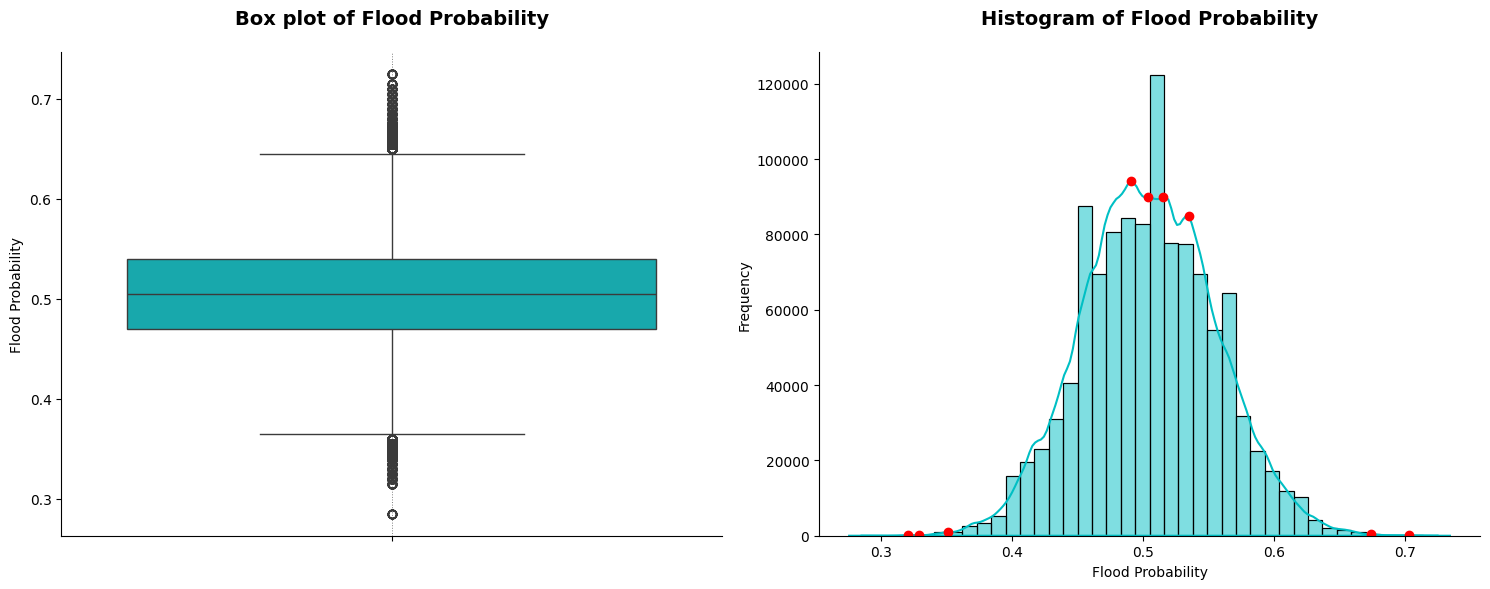

In [13]:
from scipy.signal import find_peaks
fig, ax = plt.subplots(nrows=1, ncols=2, sharey=False, figsize=(15, 6))

sns.boxplot(data=df_train, y = "FloodProbability", ax=ax[0], color="#00BFC4")
ax[0].set_title(f"Box plot of Flood Probability", fontsize=14, pad=20, weight="bold")
ax[0].grid(axis="x", color="gray", linestyle=":", linewidth=0.7)
ax[0].set_ylabel("Flood Probability")
sns.despine(ax=ax[0], top=True, right=True, left=False, bottom=False)

sns.histplot(data=df_train, x = "FloodProbability", ax=ax[1], color="#00BFC4", kde=True, bins=40)
ax[1].set_title(f"Histogram of Flood Probability", fontsize=14, pad=20, weight="bold")
ax[1].set_xlabel("Flood Probability")
ax[1].set_ylabel("Frequency")
# ax[1].grid(axis="x", color="gray", linestyle=":", linewidth=0.7)
sns.despine(ax=ax[1], top=True, right=True, left=False, bottom=False)

# Extract KDE values to find peaks
kde = sns.kdeplot(df_train["FloodProbability"], ax=ax[1], color="#00BFC4").lines[0].get_data()
kde_x, kde_y = kde[0], kde[1]
peaks, _ = find_peaks(kde_y)

# Highlight peaks
for peak_idx in peaks:
    plt.plot(kde_x[peak_idx], kde_y[peak_idx], "ro")  # Red dots on peaks

plt.tight_layout()
plt.show()

> Target variable is normally distributed around 0.5, with few realistic outliers — stable and well-suited for regression models.

## Numerical Feature Distributions

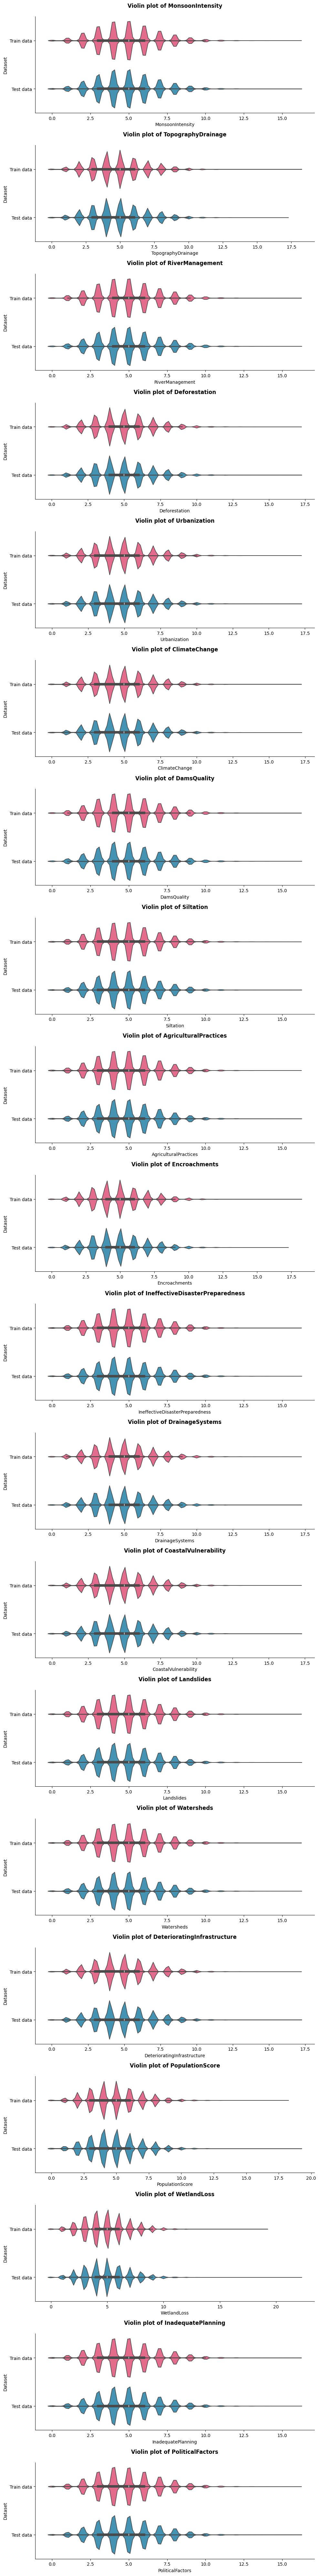

In [14]:
def plot_numerical_features(df_train, df_test, num_features):
    colors = color(n_colors=2)  # The color function you defined earlier
    n = len(num_features)

    fig, ax = plt.subplots(n, 1, figsize=(10, n * 4))
    if n == 1:
        ax = [ax]  # Ensure ax is iterable when there is only one feature

    for i, feature in enumerate(num_features):
        # Combine data for violin plot
        df_plot = pd.concat([
            pd.DataFrame({"Dataset": "Train data", feature: df_train[feature]}),
            pd.DataFrame({"Dataset": "Test data", feature: df_test[feature]})
        ]).reset_index(drop=True)

        sns.violinplot(data=df_plot, x=feature, y="Dataset",  palette=colors, ax=ax[i])
        ax[i].set_title(f"Violin plot of {feature}", pad=20, weight="bold")
        # ax[i].grid(color="gray", linestyle=":", linewidth=0.7)
        sns.despine(left=False, bottom=False, ax=ax[i])

    plt.tight_layout()
    plt.show()

# Call the function
plot_numerical_features(df_train=df_train, df_test=df_test, num_features=int_cols)

In [15]:
def check_skewness(data, dataset_name, numerical_features = int_cols, highlight=True, sort=True):
    skewness_dict = {}
    skew_feature = []
    for feature in numerical_features:
        skew = data[feature].skew(skipna=True)
        skewness_dict[feature] = skew

    skew_df = pd.DataFrame.from_dict(skewness_dict, orient="index", columns=["Skewness"])
    if sort:
        skew_df = skew_df.reindex(skew_df["Skewness"].abs().sort_values(ascending=False).index)
    
    print(f"\n🔍 Skewness for {dataset_name}:")
    print("-"*70)
    print(f"{'Feature':<30} | {'Skewness':<9} | {'Remark'}")
    print("-"*70)
    for feature, row in skew_df.iterrows():
        skew = row["Skewness"]
        abs_skew = abs(skew)
        if abs_skew > 1:
            remark = "Highly skewed"
            color = "\033[91m"  
        elif abs_skew > 0.5:
            remark = "Moderately skewed"
            color = "\033[93m"  
        else:
            remark = "Approximately symmetric"
            color = ""
        endc = "\033[0m" if color else ""
        if highlight and color:
            print(f"{color}{feature:<30} | {skew:>+9.4f} | {remark}{endc}")
            skew_feature.append(feature)
        else:
            print(f"{feature:<30} | {skew:>+9.4f} | {remark}")
    print("-"*70)
    return skew_feature, skew_df

num_features_train = ["MonsoonIntensity", "TopographyDrainage", "RiverManagement", "Deforestation", "Urbanization", 
                      "ClimateChange", "DamsQuality", "Siltation", "AgriculturalPractices", "Encroachments", 
                      "IneffectiveDisasterPreparedness", "DrainageSystems", "CoastalVulnerability", "Landslides", 
                      "Watersheds", "DeterioratingInfrastructure", "PopulationScore", "WetlandLoss", "InadequatePlanning", 
                      "PoliticalFactors", "FloodProbability"]
num_features_test = ["MonsoonIntensity", "TopographyDrainage", "RiverManagement", "Deforestation", "Urbanization", 
                      "ClimateChange", "DamsQuality", "Siltation", "AgriculturalPractices", "Encroachments", 
                      "IneffectiveDisasterPreparedness", "DrainageSystems", "CoastalVulnerability", "Landslides", 
                      "Watersheds", "DeterioratingInfrastructure", "PopulationScore", "WetlandLoss", "InadequatePlanning", 
                      "PoliticalFactors"]

skew_feature_train, skew_train_df = check_skewness(df_train, "Train Data", numerical_features=num_features_train)
skew_feature_test, skew_test_df = check_skewness(df_test, "Test Data", numerical_features=num_features_test)


🔍 Skewness for Train Data:
----------------------------------------------------------------------
Feature                        | Skewness  | Remark
----------------------------------------------------------------------
Encroachments                  |   +0.4636 | Approximately symmetric
TopographyDrainage             |   +0.4587 | Approximately symmetric
InadequatePlanning             |   +0.4551 | Approximately symmetric
PopulationScore                |   +0.4514 | Approximately symmetric
Watersheds                     |   +0.4505 | Approximately symmetric
Siltation                      |   +0.4492 | Approximately symmetric
MonsoonIntensity               |   +0.4445 | Approximately symmetric
DeterioratingInfrastructure    |   +0.4442 | Approximately symmetric
IneffectiveDisasterPreparedness |   +0.4434 | Approximately symmetric
Urbanization                   |   +0.4422 | Approximately symmetric
DrainageSystems                |   +0.4414 | Approximately symmetric
DamsQuality       

### **General Insights on Feature Distributions**

* **Overall Distribution Pattern:**

  * All features in both **train** and **test** datasets show **very low skewness** (mostly between **+0.42 and +0.46**) — meaning the distributions are **approximately symmetric**.
  * The `FloodProbability` target variable has **skewness = +0.0472**, indicating an **almost perfect normal distribution**.

* **Train Data Insights:**

  * Each feature such as `Encroachments`, `DamsQuality`, `DrainageSystems`, and `Deforestation` shows a **balanced distribution** centered around the mid-range (≈5).
  * Violin plots reveal **no significant bias or heavy tails**, confirming data uniformity.
  * Slight positive skew in some features simply reflects **natural variation** in flood-related factors.

* **Test Data Insights:**

  * Skewness values are nearly identical to the training set — typically differing by less than **±0.02**.
  * This indicates that **train and test datasets follow the same statistical distribution**, ensuring no data drift or sampling bias.
  * The feature shapes in violin plots remain consistent, confirming **excellent distribution alignment** across both datasets.

**Key Takeaways**

* Both **train** and **test** datasets exhibit **near-symmetric, well-balanced distributions** across all features.
* The **consistency** between train and test ensures **stable generalization** and **minimal preprocessing** needs.
* No heavy transformations (e.g., log, Box-Cox) are required — data is already normalized and suitable for regression modeling.

👉 **In summary:**
The overall feature distributions in both datasets are **highly consistent, nearly symmetric, and well-centered**, providing a **robust foundation for model training and evaluation**.

### Correlation Analysis of Numerical Features

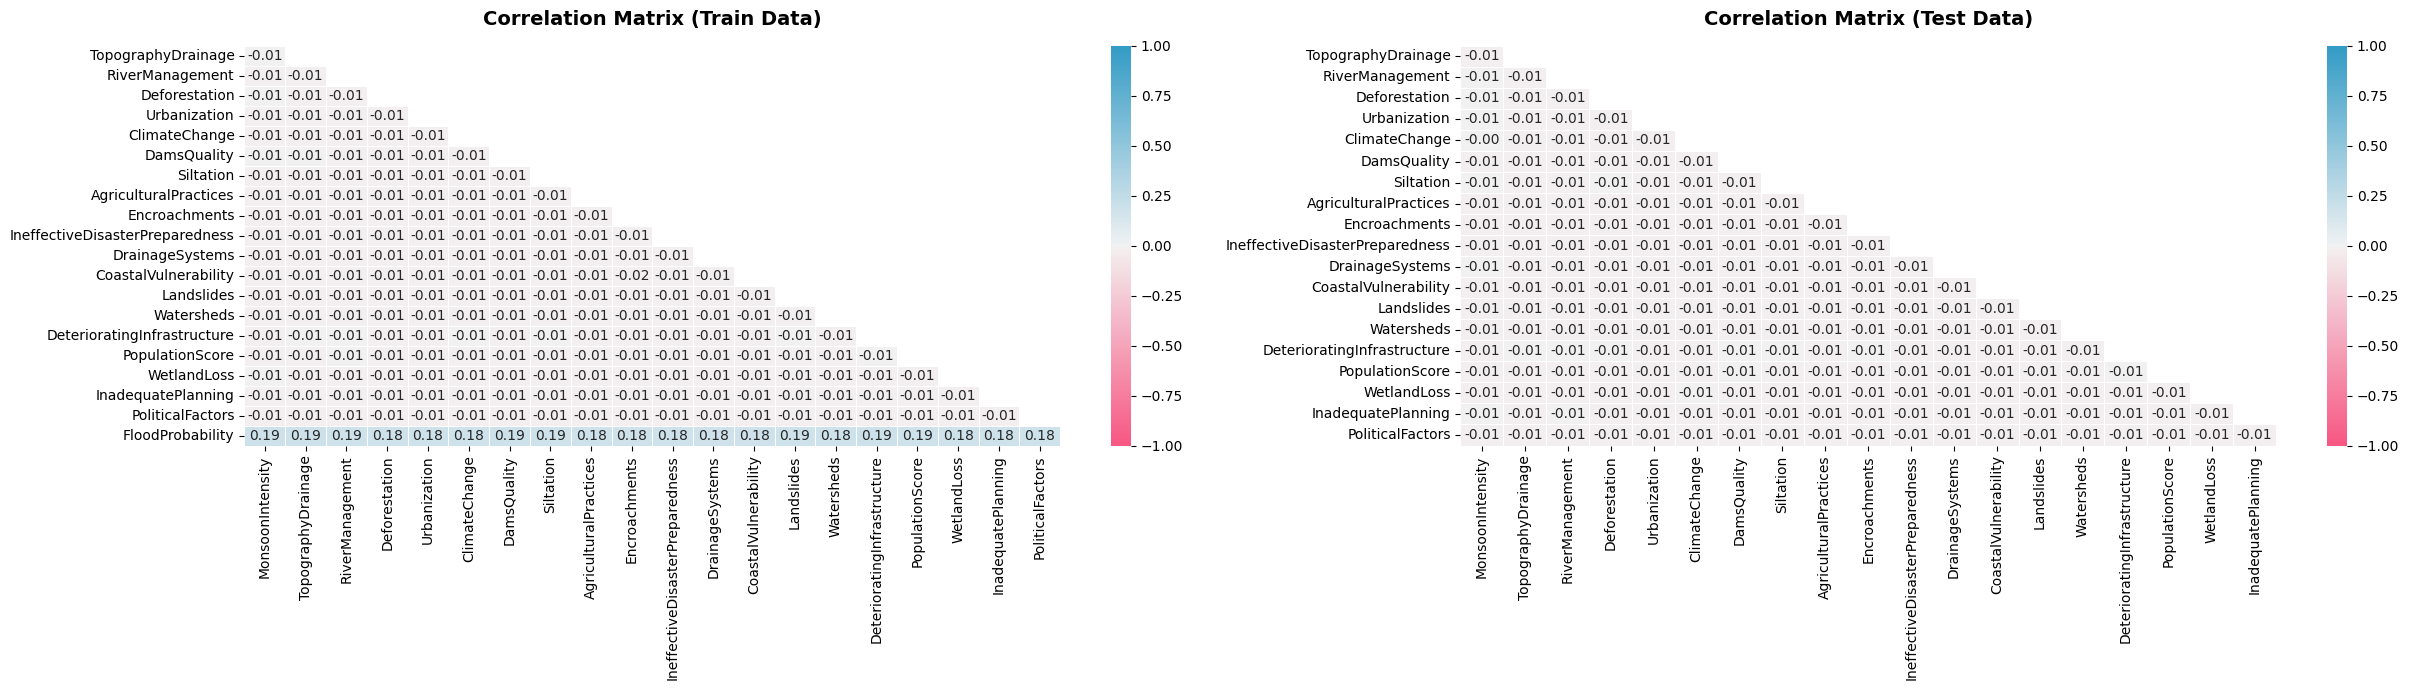

In [16]:
# --- Train correlation ---
corr_train = df_train[num_features_train].corr(numeric_only=True)
mask_train = np.triu(np.ones_like(corr_train, dtype=bool))
adjusted_mask_train = mask_train[1:, :-1]
adjusted_corr_train = corr_train.iloc[1:, :-1]

# --- Test correlation ---
corr_test = df_test[num_features_test].corr(numeric_only=True)
mask_test = np.triu(np.ones_like(corr_test, dtype=bool))
adjusted_mask_test = mask_test[1:, :-1]
adjusted_corr_test = corr_test.iloc[1:, :-1]

# --- Set up subplots ---
fig, ax = plt.subplots(1, 2, figsize=(25, 7))

# --- Custom color map ---
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

# --- Train Heatmap ---
sns.heatmap(data=adjusted_corr_train, mask=adjusted_mask_train, annot=True, fmt=".2f", 
            cmap=cmap, vmin=-1, vmax=1, linecolor="white", linewidths=0.5, ax=ax[0])
ax[0].set_title("Correlation Matrix (Train Data)", fontsize=14, weight="bold", pad=15)
# --- Test Heatmap ---
sns.heatmap(data=adjusted_corr_test, mask=adjusted_mask_test, annot=True, fmt=".2f",
            cmap=cmap, vmin=-1, vmax=1, linecolor="white", linewidths=0.5, ax=ax[1])
ax[1].set_title("Correlation Matrix (Test Data)", fontsize=14, weight="bold", pad=15)
# --- Layout ---
plt.tight_layout()
plt.show()

#### **Correlation Analysis between Features and Flood Probability**

* The correlation heatmaps for both **train** and **test** datasets show **very weak correlations** between `FloodProbability` and all predictor variables.
* The average correlation values range from **+0.18 to +0.19**, with `MonsoonIntensity`, `DrainageSystems`, and `RiverManagement` showing slightly higher positive relationships.
* This indicates that each feature individually contributes **marginally** to explaining flood probability, suggesting that the overall model performance will rely on **combined multi-feature interactions** rather than any single dominant variable.
* The **consistency** of the correlation patterns between train and test confirms **stable data relationships** and **no sign of data drift**.

**In summary:**
The correlation between input features and flood probability is **weak but stable**, implying that **complex, non-linear models (e.g., tree-based ensembles)** are likely better suited than simple linear regressions for capturing the underlying relationships.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Preprocessing</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Preprocessing
    </h1>
</div>

## Feature Engineering

In [17]:
def feature_engineering(df):
    df = df.copy()
    
    # --- Interaction Features ---
    df["Rain_Urban"] = df["MonsoonIntensity"] * df["Urbanization"]
    df["Forest_River"] = df["Deforestation"] * df["RiverManagement"]
    df["Dams_Drainage"] = df["DamsQuality"] * df["DrainageSystems"]

    # --- Group Risk Indices ---
    natural_cols = [
        "MonsoonIntensity", "TopographyDrainage", "Landslides",
        "ClimateChange", "Siltation", "Watersheds"
    ]
    df["NaturalRisk"] = df[natural_cols].mean(axis=1)

    human_cols = [
        "Urbanization", "Deforestation", "DrainageSystems",
        "DamsQuality", "InadequatePlanning", "DeterioratingInfrastructure"
    ]
    df["InfrastructureRisk"] = df[human_cols].mean(axis=1)

    governance_cols = [
        "Encroachments", "IneffectiveDisasterPreparedness",
        "PoliticalFactors", "PopulationScore"
    ]
    df["GovernanceRisk"] = df[governance_cols].mean(axis=1)

    # --- Nonlinear Transformations ---
    nonlinear_cols = ["MonsoonIntensity", "Urbanization", "DrainageSystems"]
    for col in nonlinear_cols:
        df[f"{col}_squared"] = df[col].astype(np.int16) ** 2
        df[f"{col}_sqrt"] = np.sqrt(df[col].astype(np.float32))
    
    return df


df_train_fe = feature_engineering(df_train)
df_test_fe  = feature_engineering(df_test)

# Check the shape difference
print(f"Train shape before: {df_train.shape} → after: {df_train_fe.shape}")
print(f"Test shape before:  {df_test.shape}  → after: {df_test_fe.shape}")

# Display few rows of each dataset
print("Train Data Preview:")
display(df_train_fe.head())

print("\nTest Data Preview:")
display(df_test_fe.head())

Train shape before: (1117957, 21) → after: (1117957, 33)
Test shape before:  (745305, 20)  → after: (745305, 32)
Train Data Preview:


,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,IneffectiveDisasterPreparedness,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability,Rain_Urban,Forest_River,Dams_Drainage,NaturalRisk,InfrastructureRisk,GovernanceRisk,MonsoonIntensity_squared,MonsoonIntensity_sqrt,Urbanization_squared,Urbanization_sqrt,DrainageSystems_squared,DrainageSystems_sqrt
0,5,8,5,8,6,4,4,3,3,4,2,5,3,3,5,4,7,5,7,3,0.445,30,40,20,4.666667,5.666667,4.00,25,2.236068,36,2.449490,25,2.236068
1,6,7,4,4,8,8,3,5,4,6,9,7,2,0,3,5,3,3,4,3,0.450,48,16,21,4.833333,5.166667,5.25,36,2.449490,64,2.828427,49,2.645751
2,6,5,6,7,3,7,1,5,4,5,6,7,3,7,5,6,8,2,3,3,0.530,18,42,7,5.833333,4.500000,5.50,36,2.449490,9,1.732051,49,2.645751
3,3,4,6,5,4,8,4,7,6,8,5,2,4,7,4,4,6,5,7,5,0.535,12,30,8,5.500000,4.333333,6.00,9,1.732051,16,2.000000,4,1.414214
4,5,3,2,6,4,4,3,3,3,3,5,2,2,6,6,4,1,2,3,5,0.415,20,12,6,4.500000,3.666667,3.50,25,2.236068,16,2.000000,4,1.414214



Test Data Preview:


,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,IneffectiveDisasterPreparedness,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,Rain_Urban,Forest_River,Dams_Drainage,NaturalRisk,InfrastructureRisk,GovernanceRisk,MonsoonIntensity_squared,MonsoonIntensity_sqrt,Urbanization_squared,Urbanization_sqrt,DrainageSystems_squared,DrainageSystems_sqrt
0,4,6,3,5,6,7,8,7,8,4,8,5,7,5,6,3,6,4,4,5,24,15,40,5.833333,5.166667,5.75,16,2.000000,36,2.449490,25,2.236068
1,4,4,2,9,5,5,4,7,5,4,2,4,7,4,5,1,7,4,4,3,20,18,16,4.833333,4.500000,4.00,16,2.000000,25,2.236068,16,2.000000
2,1,3,6,5,7,2,4,6,4,2,7,9,2,5,5,2,3,6,8,3,7,30,36,3.666667,5.833333,3.75,1,1.000000,49,2.645751,81,3.000000
3,2,4,4,6,4,5,4,3,4,4,7,8,4,6,7,6,4,2,4,4,8,24,32,4.500000,5.333333,4.75,4,1.414214,16,2.000000,64,2.828427
4,6,3,2,4,6,4,5,5,3,7,4,3,2,6,4,6,8,4,5,5,36,8,15,4.666667,4.833333,6.00,36,2.449490,36,2.449490,9,1.732051


In [18]:
# Check memory before
print("Before conversion:")
print(df_train_fe.info(memory_usage="deep"))
print(df_test_fe.info(memory_usage="deep"))

# Identify float columns (excluding target)
float_cols_train = df_train_fe.select_dtypes(include=["float64"]).columns.tolist()
float_cols_test = df_test_fe.select_dtypes(include=["float64"]).columns.tolist()

# Convert float64 columns to float32
df_train_fe[float_cols_train] = df_train_fe[float_cols_train].astype("float32")
df_test_fe[float_cols_test] = df_test_fe[float_cols_test].astype("float32")

# Check after conversion
print("\nAfter conversion:")
print(df_train_fe.info(memory_usage="deep"))
print(df_test_fe.info(memory_usage="deep"))

Before conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1117957 entries, 0 to 1117956
Data columns (total 33 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   MonsoonIntensity                 1117957 non-null  int8   
 1   TopographyDrainage               1117957 non-null  int8   
 2   RiverManagement                  1117957 non-null  int8   
 3   Deforestation                    1117957 non-null  int8   
 4   Urbanization                     1117957 non-null  int8   
 5   ClimateChange                    1117957 non-null  int8   
 6   DamsQuality                      1117957 non-null  int8   
 7   Siltation                        1117957 non-null  int8   
 8   AgriculturalPractices            1117957 non-null  int8   
 9   Encroachments                    1117957 non-null  int8   
 10  IneffectiveDisasterPreparedness  1117957 non-null  int8   
 11  DrainageSystems                

## Re-checking Skewness

In [19]:
num_features_train = df_train_fe.select_dtypes(include=[np.number]).columns.tolist()
skew_feature_train, skew_train_df = check_skewness(data=df_train_fe, dataset_name="Train Data",
                                                   numerical_features=num_features_train)


🔍 Skewness for Train Data:
----------------------------------------------------------------------
Feature                        | Skewness  | Remark
----------------------------------------------------------------------
MonsoonIntensity_squared       |   +1.7606 | Highly skewed
DrainageSystems_squared        |   +1.7242 | Highly skewed
Urbanization_squared           |   +1.6989 | Highly skewed
Rain_Urban                     |   +1.0877 | Highly skewed
Dams_Drainage                  |   +1.0816 | Highly skewed
Forest_River                   |   +1.0782 | Highly skewed
DrainageSystems_sqrt           |   -0.4774 | Approximately symmetric
MonsoonIntensity_sqrt          |   -0.4746 | Approximately symmetric
Encroachments                  |   +0.4636 | Approximately symmetric
TopographyDrainage             |   +0.4587 | Approximately symmetric
InadequatePlanning             |   +0.4551 | Approximately symmetric
Urbanization_sqrt              |   -0.4548 | Approximately symmetric
Population

In [20]:
num_features_test = df_test_fe.select_dtypes(include=[np.number]).columns.tolist()
skew_feature_test, skew_test_df = check_skewness(data=df_test_fe, dataset_name="Test Data",
                                                 numerical_features=num_features_test)


🔍 Skewness for Test Data:
----------------------------------------------------------------------
Feature                        | Skewness  | Remark
----------------------------------------------------------------------
MonsoonIntensity_squared       |   +1.7387 | Highly skewed
Urbanization_squared           |   +1.7216 | Highly skewed
DrainageSystems_squared        |   +1.7132 | Highly skewed
Dams_Drainage                  |   +1.0752 | Highly skewed
Rain_Urban                     |   +1.0697 | Highly skewed
Forest_River                   |   +1.0661 | Highly skewed
DrainageSystems_sqrt           |   -0.4866 | Approximately symmetric
MonsoonIntensity_sqrt          |   -0.4834 | Approximately symmetric
TopographyDrainage             |   +0.4604 | Approximately symmetric
Urbanization_sqrt              |   -0.4570 | Approximately symmetric
Siltation                      |   +0.4547 | Approximately symmetric
Encroachments                  |   +0.4545 | Approximately symmetric
InadequateP

In [21]:
from sklearn.preprocessing import PowerTransformer

def handle_skewed_features(df, zero_threshold=0.9, skew_threshold=0.5, num_features=None, exclude_cols=None):
    """
    Handle skewed numerical features by applying appropriate transformations,
    *forcing* certain columns to be transformed even if they don't exceed skew_threshold.

    Parameters:
    - df: pandas.DataFrame
    - zero_threshold: float (default=0.9)
    - skew_threshold: float (default=0.5)
    - num_features: list of numerical columns to consider
    - exclude_cols: list of columns to skip entirely
    - dataset: Name of dataset

    Returns:
    - df: transformed DataFrame
    - transformed_cols: list of new feature names
    - high_zero_cols: list of sparse features (> zero_threshold)
    - skewed_cols: list of auto‑detected skewed features
    - pt_dict: dict mapping each YJ‑transformed col → its PowerTransformer
    """
    df = df.copy()
    if num_features is None:
        raise ValueError("`num_features` must be provided")
    if exclude_cols is None:
        exclude_cols = []

    # 1) pick the numeric cols to scan
    numerical_cols = [c for c in num_features if c not in exclude_cols]

    # 2) detect ultra‑sparse
    zero_ratios = (df[numerical_cols] == 0).sum() / len(df)
    high_zero_cols = zero_ratios[zero_ratios > zero_threshold].index.tolist()

    # 3) compute skew
    skew_vals = df[numerical_cols].apply(lambda s: skew(s.dropna()))
    auto_skewed = skew_vals[abs(skew_vals) > skew_threshold].index.tolist()

    # 4) union these with your forced list
    to_transform = list(set(auto_skewed))

    transformed_cols = []
    dropped_cols     = []
    pt_dict          = {}

    for col in to_transform:
        # if it's sparse → binary+log
        if col in high_zero_cols:
            df[f"Has_{col}"] = (df[col] > 0).astype(int)
            df[f"Log_{col}"] = df[col].map(lambda x: np.log1p(x) if x > 0 else 0)
            transformed_cols += [f"Has_{col}", f"Log_{col}"]
            dropped_cols.append(col)
        # if it's discrete small‑cardinality, skip transform but keep
        elif df[col].nunique() <= 5:
            # do nothing (we still keep raw col in df)
            continue
        # otherwise apply Yeo‑Johnson
        else:
            pt = PowerTransformer(method="yeo-johnson")
            arr = df[[col]].values  # shape (n,1)
            df[f"PT_{col}"] = pt.fit_transform(arr)
            pt_dict[col] = pt
            transformed_cols.append(f"PT_{col}")
            dropped_cols.append(col)

    # drop originals for any column we did transform
    df.drop(columns=dropped_cols, inplace=True)

    return df, transformed_cols, high_zero_cols, auto_skewed, pt_dict

In [22]:
processed_train_df, transformed_columns, sparse_columns, skewed_columns, pt_dict_train = handle_skewed_features(df=df_train_fe, num_features=skew_feature_train)
num_features_train = ["MonsoonIntensity", "TopographyDrainage", "RiverManagement", "Deforestation", "Urbanization", "ClimateChange", "DamsQuality",
                      "Siltation", "AgriculturalPractices", "Encroachments", "IneffectiveDisasterPreparedness", "DrainageSystems", "CoastalVulnerability",
                      "Landslides", "Watersheds", "DeterioratingInfrastructure", "PopulationScore", "WetlandLoss", "InadequatePlanning", "PoliticalFactors",
                      "FloodProbability", "PT_Rain_Urban", "PT_Forest_River", "PT_Dams_Drainage", "NaturalRisk", "InfrastructureRisk", "GovernanceRisk", "PT_MonsoonIntensity_squared",
                      "MonsoonIntensity_sqrt", "PT_Urbanization_squared", "Urbanization_sqrt", "PT_DrainageSystems_squared", "DrainageSystems_sqrt"]
skew_feature_train, skew_train_df = check_skewness(data=processed_train_df, numerical_features=num_features_train,
                                                   dataset_name= "Train data")


🔍 Skewness for Train data:
----------------------------------------------------------------------
Feature                        | Skewness  | Remark
----------------------------------------------------------------------
DrainageSystems_sqrt           |   -0.4774 | Approximately symmetric
MonsoonIntensity_sqrt          |   -0.4746 | Approximately symmetric
Encroachments                  |   +0.4636 | Approximately symmetric
TopographyDrainage             |   +0.4587 | Approximately symmetric
InadequatePlanning             |   +0.4551 | Approximately symmetric
Urbanization_sqrt              |   -0.4548 | Approximately symmetric
PopulationScore                |   +0.4514 | Approximately symmetric
Watersheds                     |   +0.4505 | Approximately symmetric
Siltation                      |   +0.4492 | Approximately symmetric
MonsoonIntensity               |   +0.4445 | Approximately symmetric
DeterioratingInfrastructure    |   +0.4442 | Approximately symmetric
IneffectiveDisaster

In [23]:
processed_test_df, transformed_columns_test, sparse_columns_test, skewed_columns_test, pt_dict_test = handle_skewed_features(df=df_test_fe, num_features=skew_feature_test)
num_features_test = ["MonsoonIntensity", "TopographyDrainage", "RiverManagement", "Deforestation", "Urbanization", "ClimateChange", "DamsQuality",
                      "Siltation", "AgriculturalPractices", "Encroachments", "IneffectiveDisasterPreparedness", "DrainageSystems", "CoastalVulnerability",
                      "Landslides", "Watersheds", "DeterioratingInfrastructure", "PopulationScore", "WetlandLoss", "InadequatePlanning", "PoliticalFactors",
                      "PT_Rain_Urban", "PT_Forest_River", "PT_Dams_Drainage", "NaturalRisk", "InfrastructureRisk", "GovernanceRisk", "PT_MonsoonIntensity_squared",
                      "MonsoonIntensity_sqrt", "PT_Urbanization_squared", "Urbanization_sqrt", "PT_DrainageSystems_squared", "DrainageSystems_sqrt"]
skew_feature_test, skew_test_df = check_skewness(data=processed_test_df, numerical_features=num_features_test,
                                                   dataset_name= "Test data")


🔍 Skewness for Test data:
----------------------------------------------------------------------
Feature                        | Skewness  | Remark
----------------------------------------------------------------------
DrainageSystems_sqrt           |   -0.4866 | Approximately symmetric
MonsoonIntensity_sqrt          |   -0.4834 | Approximately symmetric
TopographyDrainage             |   +0.4604 | Approximately symmetric
Urbanization_sqrt              |   -0.4570 | Approximately symmetric
Siltation                      |   +0.4547 | Approximately symmetric
Encroachments                  |   +0.4545 | Approximately symmetric
InadequatePlanning             |   +0.4523 | Approximately symmetric
Watersheds                     |   +0.4506 | Approximately symmetric
IneffectiveDisasterPreparedness |   +0.4497 | Approximately symmetric
Urbanization                   |   +0.4489 | Approximately symmetric
PopulationScore                |   +0.4473 | Approximately symmetric
PoliticalFactors   

**Observations from the Skewness Table (`processed_train_df` and `processed_test_df`):**

✅ **Approximately Symmetric**:

* Several features, such as:

  * `MonsoonIntensity_squared`, `Urbanization_squared`, `DrainageSystems_squared`, `Dams_Drainage`, `Rain_Urban`, `Forest_River` less than 0.5.
  * This indicates that **Yeo-Johnson transformation was effective** for these features.

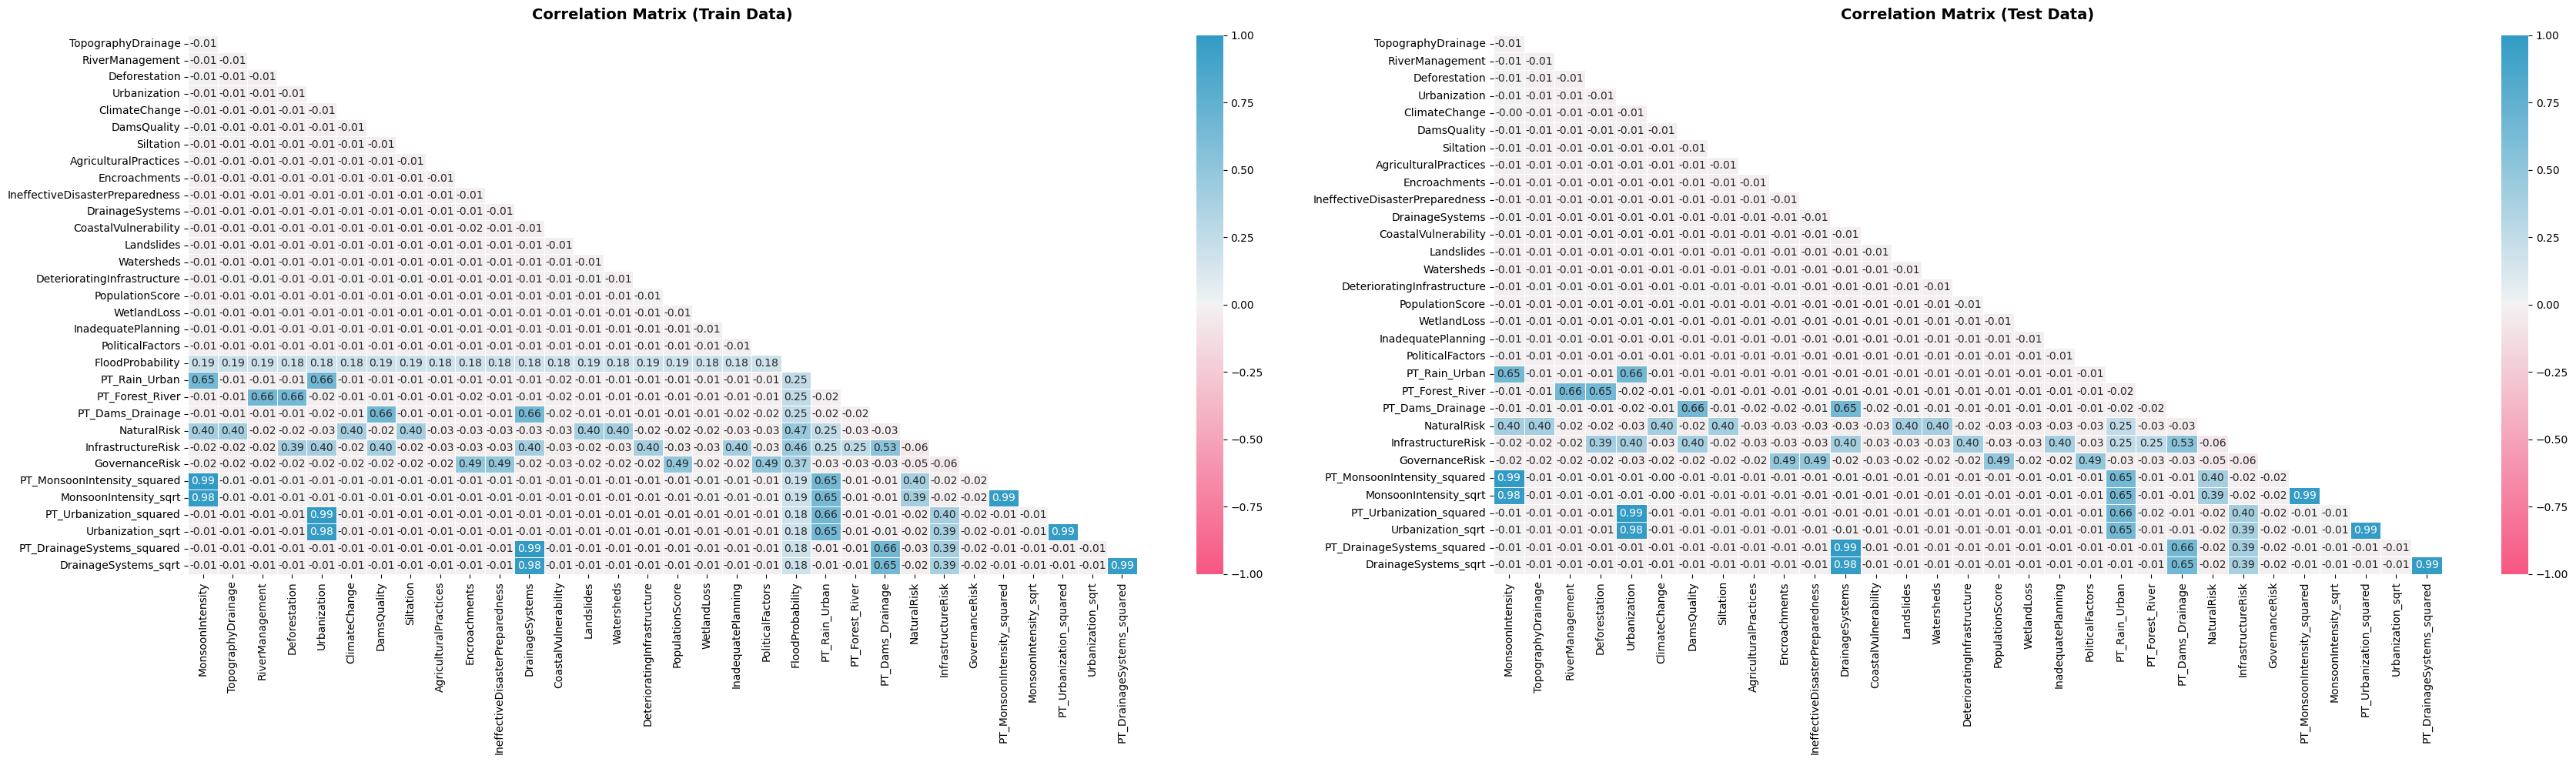

In [24]:
# --- Train correlation ---
corr_train = processed_train_df[num_features_train].corr(numeric_only=True)
mask_train = np.triu(np.ones_like(corr_train, dtype=bool))
adjusted_mask_train = mask_train[1:, :-1]
adjusted_corr_train = corr_train.iloc[1:, :-1]

# --- Test correlation ---
corr_test = processed_test_df[num_features_test].corr(numeric_only=True)
mask_test = np.triu(np.ones_like(corr_test, dtype=bool))
adjusted_mask_test = mask_test[1:, :-1]
adjusted_corr_test = corr_test.iloc[1:, :-1]

# --- Set up subplots ---
fig, ax = plt.subplots(1, 2, figsize=(35, 10))

# --- Custom color map ---
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

# --- Train Heatmap ---
sns.heatmap(data=adjusted_corr_train, mask=adjusted_mask_train, annot=True, fmt=".2f", 
            cmap=cmap, vmin=-1, vmax=1, linecolor="white", linewidths=0.5, ax=ax[0])
ax[0].set_title("Correlation Matrix (Train Data)", fontsize=14, weight="bold", pad=15)
# --- Test Heatmap ---
sns.heatmap(data=adjusted_corr_test, mask=adjusted_mask_test, annot=True, fmt=".2f",
            cmap=cmap, vmin=-1, vmax=1, linecolor="white", linewidths=0.5, ax=ax[1])
ax[1].set_title("Correlation Matrix (Test Data)", fontsize=14, weight="bold", pad=15)
# --- Layout ---
plt.tight_layout()
plt.show()

**Correlation Analysis after Feature Engineering**

* The extended correlation heatmaps for **train** and **test** datasets show that most of the original variables still have **weak individual correlations** (|r| < 0.2) with `FloodProbability`.
  → This confirms that the target is influenced by **combined, non-linear effects** rather than any single predictor.

* Newly engineered features exhibit **stronger internal relationships**:

  * High correlations between squared and square-root forms (e.g. `MonsoonIntensity_squared ↔ MonsoonIntensity_sqrt ≈ 0.90`) — expected due to mathematical dependency.
  * **Interaction features** such as `Rain_Urban`, `Forest_River`, and `Dams_Drainage` show moderate correlations with their respective components (≈ 0.65–0.67), confirming logical feature interactions.
  * Grouped indices like `NaturalRisk` and `InfrastructureRisk` display **meaningful aggregated relationships** (≈ 0.40–0.43) with individual environmental features, proving their validity as combined indicators.

* The correlation structure between **train** and **test** remains **highly consistent**, ensuring that the engineered features generalize well without introducing data drift.

**Key Takeaways**

* Feature engineering has **enriched the dataset** with more informative and interpretable variables.
* While direct correlations with the target remain low, the engineered features improve **interaction capture** and **nonlinear representation**, which are essential for complex models like LightGBM or XGBoost.
* The stable correlation pattern across both datasets reinforces **data reliability and generalization potential**.

## Re-check Outliers

In [25]:
checking_outlier(list_feature=num_features_train, df=processed_train_df, dataset_name="Training Data")

🔍 Training Data - Checking Outliers

⚠️ Outlier Summary (Training Data):


,Feature,Outlier Count,Outlier %
0,PT_DrainageSystems_squared,58983,5.2760
1,DrainageSystems_sqrt,58983,5.2760
2,Encroachments,31141,2.7855
3,DamsQuality,31097,2.7816
4,DrainageSystems,30060,2.6888
5,RiverManagement,29617,2.6492
6,WetlandLoss,29499,2.6387
7,PT_Dams_Drainage,29065,2.5998
8,Deforestation,28235,2.5256
9,PT_Forest_River,28207,2.5231



Total features with outliers: 33/33


In [26]:
checking_outlier(list_feature=num_features_test, df=processed_test_df, dataset_name="Test Data")

🔍 Test Data - Checking Outliers

⚠️ Outlier Summary (Test Data):


,Feature,Outlier Count,Outlier %
0,PT_DrainageSystems_squared,39518,5.3023
1,DrainageSystems_sqrt,39518,5.3023
2,DamsQuality,20905,2.8049
3,Encroachments,20471,2.7467
4,DrainageSystems,20090,2.6955
5,RiverManagement,19911,2.6715
6,PT_Dams_Drainage,19539,2.6216
7,WetlandLoss,19507,2.6173
8,Deforestation,18972,2.5455
9,PT_Forest_River,18917,2.5382



Total features with outliers: 32/32


## Create Test Set

Suppose we chatted with experts who told us that the **NaturalRisk** is a very important attribute to predict **FloodProbability**. We may want to ensure that the test set is representative of the various categories of **NaturalRisk** in the whole dataset. Since the **NaturalRisk** is a continuous numerical attribute, we first need to create an category attribute.

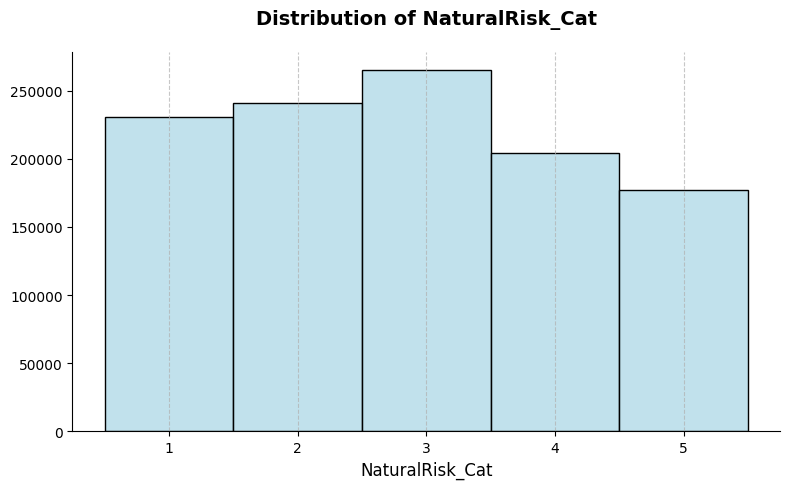

In [27]:
processed_train_df["NaturalRisk_Cat"] = pd.qcut(processed_train_df["NaturalRisk"],
                                              q=5,
                                              labels=[1, 2, 3, 4, 5])

plt.figure(figsize=(8, 5))
sns.histplot(data=processed_train_df, x="NaturalRisk_Cat", color="lightblue", edgecolor="black")
sns.despine(top=True, right=True, left=False, bottom=False)
plt.title("Distribution of NaturalRisk_Cat", fontsize=14, weight="bold", pad=20)
plt.xlabel("NaturalRisk_Cat", fontsize=12)
plt.ylabel("")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [28]:
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, val_index in split.split(processed_train_df, processed_train_df["NaturalRisk_Cat"]):
    start_train_set = processed_train_df.iloc[train_index]
    start_val_set = processed_train_df.iloc[val_index]

In [29]:
# Now we should remove the NaturalRisk_Cat attribute so the data is back to its original state:
for set_ in (start_train_set, start_val_set): 
    set_.drop("NaturalRisk_Cat", axis=1, inplace=True)

## Scale and Ecode

In [30]:
df_train_new = start_train_set.drop("FloodProbability", axis=1)
df_train_label_new = start_train_set["FloodProbability"].copy()

In [31]:
robust_features = [
    "PT_DrainageSystems_squared", "DrainageSystems_sqrt",
    "Encroachments", "DamsQuality", "DrainageSystems",
    "RiverManagement", "WetlandLoss", "PT_Dams_Drainage",
    "Deforestation", "PT_Forest_River", "PT_Rain_Urban"
]

standard_features = [
    "CoastalVulnerability", "PoliticalFactors", "TopographyDrainage",
    "InadequatePlanning", "PopulationScore", "Watersheds",
    "MonsoonIntensity", "Urbanization", "Siltation", "AgriculturalPractices",
    "DeterioratingInfrastructure", "IneffectiveDisasterPreparedness",
    "Landslides", "ClimateChange",
    "NaturalRisk", "InfrastructureRisk", "GovernanceRisk",
    "MonsoonIntensity_sqrt", "Urbanization_sqrt",
    "PT_MonsoonIntensity_squared", "PT_Urbanization_squared"
]

num_robust_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

num_stand_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ("num_robust", num_robust_transformer, robust_features),
    ("num_stand", num_stand_transformer, standard_features)
])

preprocessor.fit(df_train_new)
df_train_new_prepared = preprocessor.transform(df_train_new)
list_feature_prepared = preprocessor.get_feature_names_out().tolist()
clean_features = [col.replace("num_stand__", "").replace("num_robust__", "") for col in list_feature_prepared]
clean_features_2 = [col.replace("PT_", "") for col in clean_features]
clean_features_2

['DrainageSystems_squared',
 'DrainageSystems_sqrt',
 'Encroachments',
 'DamsQuality',
 'DrainageSystems',
 'RiverManagement',
 'WetlandLoss',
 'Dams_Drainage',
 'Deforestation',
 'Forest_River',
 'Rain_Urban',
 'CoastalVulnerability',
 'PoliticalFactors',
 'TopographyDrainage',
 'InadequatePlanning',
 'PopulationScore',
 'Watersheds',
 'MonsoonIntensity',
 'Urbanization',
 'Siltation',
 'AgriculturalPractices',
 'DeterioratingInfrastructure',
 'IneffectiveDisasterPreparedness',
 'Landslides',
 'ClimateChange',
 'NaturalRisk',
 'InfrastructureRisk',
 'GovernanceRisk',
 'MonsoonIntensity_sqrt',
 'Urbanization_sqrt',
 'MonsoonIntensity_squared',
 'Urbanization_squared']

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Define Metric</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Define Metric
    </h1>
</div>

## Coefficient of Determination (R² Score)

**Definition:**

**R² (Coefficient of Determination)** measures how well a regression model explains the variability of the target variable.
It represents the **proportion of the variance** in the dependent variable that is predictable from the independent variables.

**Formula:**

$$
R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}*i)^2}{\sum*{i=1}^{n} (y_i - \bar{y})^2}
$$

* $y_i$: Actual (true) value
* $\hat{y}_i$: Predicted value
* $\bar{y}$: Mean of the actual values
* $n$: Number of observations

**Characteristics:**

* R² ranges from **−∞ to 1**:

  * **R² = 1** → Perfect prediction (model explains 100% of the variance).
  * **R² = 0** → Model performs no better than the mean.
  * **R² < 0** → Model performs worse than simply predicting the mean.
* Higher R² indicates a **better fit** of the model to the data.
* R² does **not indicate bias** or whether predictions are systematically over/underestimated.
* It is **scale-independent**, making it convenient for comparing models.

**References:**

* [Scikit-learn Documentation – R² Score](https://scikit-learn.org/stable/modules/model_evaluation.html#r2-score)
* [Kaggle Discussion: Understanding R² in Regression](https://www.kaggle.com/discussions/getting-started/219190)

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Modeling</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Modeling
    </h1>
</div>

In [32]:
def shap_plot(model, X_test, list_feature, type = None):    
     # https://towardsdatascience.com/using-shap-values-to-explain-how-your-machine-learning-model-works-732b3f40e137/
    if hasattr(X_test, "toarray"):
        X_test = X_test.toarray()
    X_test_sample = pd.DataFrame(X_test, columns=list_feature)
    explainer = shap.Explainer(model.predict, X_test_sample)
    shap_values = explainer(X_test_sample)
    if type =="bar":
        shap_importance = np.abs(shap_values.values).mean(axis=0)
        shap_df = pd.DataFrame({"feature": X_test_sample.columns, "importance": shap_importance})
        shap_df = shap_df.sort_values("importance", ascending=False).head(20)
        plt.figure(figsize=(12, 6))
        sns.barplot(x=shap_df["importance"], y=shap_df["feature"], palette="viridis", order=shap_df["feature"])
        plt.xlabel("mean(|SHAP value|)")
        plt.title("SHAP Feature Importance", fontsize=14, weight="bold", pad=20)
        plt.tight_layout()
        plt.show()
    else:
        shap.summary_plot(shap_values, X_test_sample)

In [33]:
# Function to evaluate regression models
def evaluate_model(model, X_train, X_val, y_train, y_val):
    RESET = "\033[0m"
    BLUE = "\033[94m"
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    y_val_real = y_val
    y_pred_real = y_pred
    
    # Metrics: R2
    r2 = r2_score(y_val_real, y_pred_real)
    print(f"Model: {model.__class__.__name__}{RESET}")
    print(f"Coefficient of Determination (R2): {BLUE}{r2:.4f}{RESET}")
    print("-" * 80)

    fig, axs = plt.subplots(1, 2, figsize=(14, 7))

    # ----- Plot 1: Predicted vs. Actual -----
    axs[0].scatter(y_val_real, y_pred_real, alpha=0.5, color="royalblue", edgecolors="none", rasterized=True, s=10)
    axs[0].plot(
        [y_val_real.min(), y_val_real.max()],
        [y_val_real.min(), y_val_real.max()],
        "r--", lw=2, label="Perfect Prediction (y=x)"
    )
    axs[0].set_xlabel("Actual Values (FloodProbability)")
    axs[0].set_ylabel("Predicted Values (FloodProbability)")
    axs[0].set_title("Predicted vs. Actual (Validation Set)", fontsize=14, weight="bold", pad=20)
    axs[0].legend()
    axs[0].grid(True, alpha=0.2)

    # ----- Plot 2: Residual Plot -----
    residuals = y_val_real - y_pred_real
    axs[1].scatter(y_val_real, residuals, alpha=0.5, color="royalblue", edgecolors="none", rasterized=True, s=10)
    axs[1].axhline(0, color="red", linestyle="--", lw=2)
    axs[1].set_xlabel("Actual Values (FloodProbability)")
    axs[1].set_ylabel("Prediction Error (Residuals)")
    axs[1].set_title("Residual Plot", fontsize=14, weight="bold", pad=20)
    axs[1].grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

In [34]:
X_val = start_val_set.drop("FloodProbability", axis=1)
y_val = start_val_set["FloodProbability"].copy()
X_val_prepared = preprocessor.transform(X_val)

## CatBoostRegressor

Model: CatBoostRegressor
Coefficient of Determination (R2): 0.8512
--------------------------------------------------------------------------------


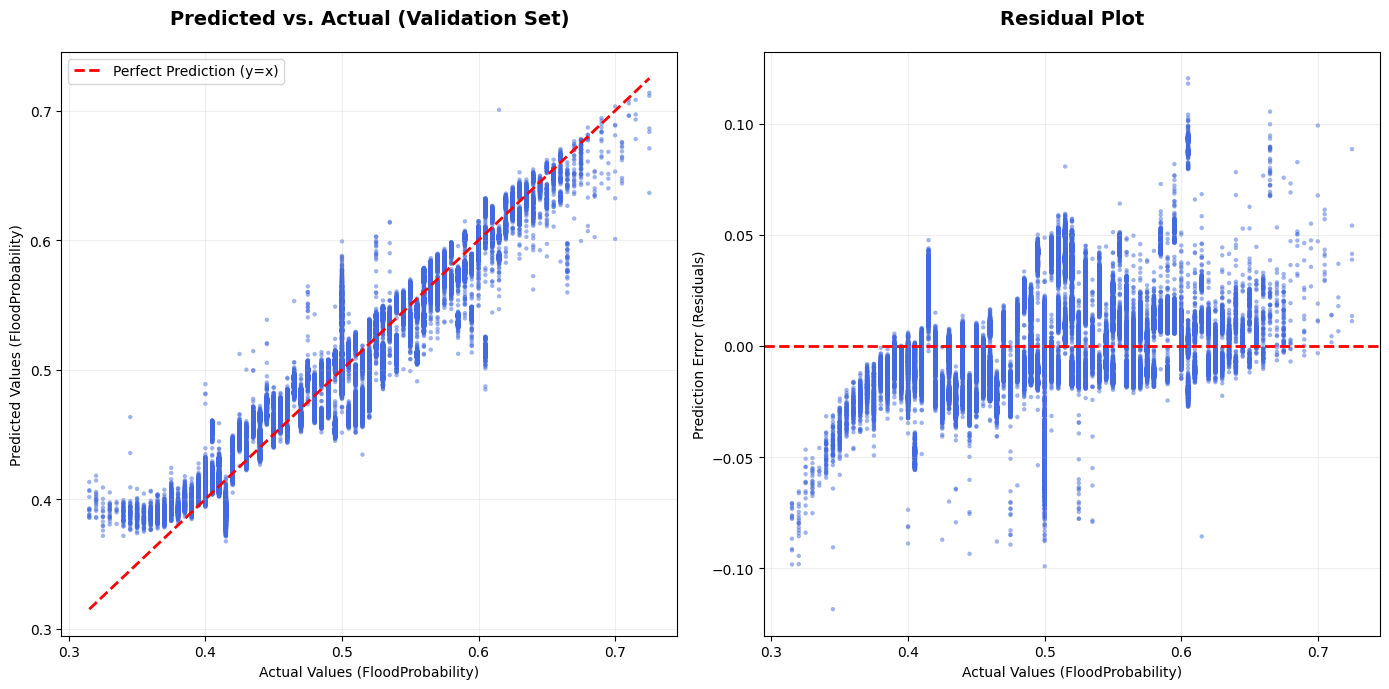

In [37]:
from catboost import CatBoostRegressor

cat_params = {
    "n_estimators":12000,
    "l2_leaf_reg": 0.0017992898021052064, 
    "max_bin": 200, 
    "learning_rate": 0.016714889518285515, 
    "max_depth": 7, 
    "min_data_in_leaf": 288,
    "random_seed": 42,
    "loss_function": "RMSE",
    "eval_metric": "R2",
    "verbose": 0,
    "allow_writing_files": False,
    "bootstrap_type": "Bernoulli",
    "thread_count": -1
}

model_cb = CatBoostRegressor(**cat_params)
evaluate_model(model = model_cb, X_train = df_train_new_prepared, 
               X_val = X_val_prepared , y_train = df_train_label_new, y_val=y_val)

**Model Performance Overview (CatBoost Regressor)**

* **High accuracy and stability** — predictions align closely with actual values across the distribution.
* **No evident bias**, as residuals are symmetrically distributed around zero.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Conclusion</span>

<div style="
    border-radius: 15px;
    border: 2px solid #003366;
    padding: 10px;
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff);
    text-align: center;
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF;
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7);
        font-weight: bold;
        margin-bottom: 5px;
        font-size: 28px;
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Conclusion
    </h1>
</div>

In [40]:
df_test_prepared = preprocessor.transform(processed_test_df)
y_pred_test = model_cb.predict(df_test_prepared)

submission_df = pd.DataFrame({
    "id": list_test_id,
    "FloodProbability": y_pred_test
})

submission_df.to_csv("submission.csv", index=False)
print("\nSubmission file saved!")
submission_df.head(5)


Submission file saved!


,id,FloodProbability
0,1117957,0.575138
1,1117958,0.452411
2,1117959,0.452228
3,1117960,0.464009
4,1117961,0.462989


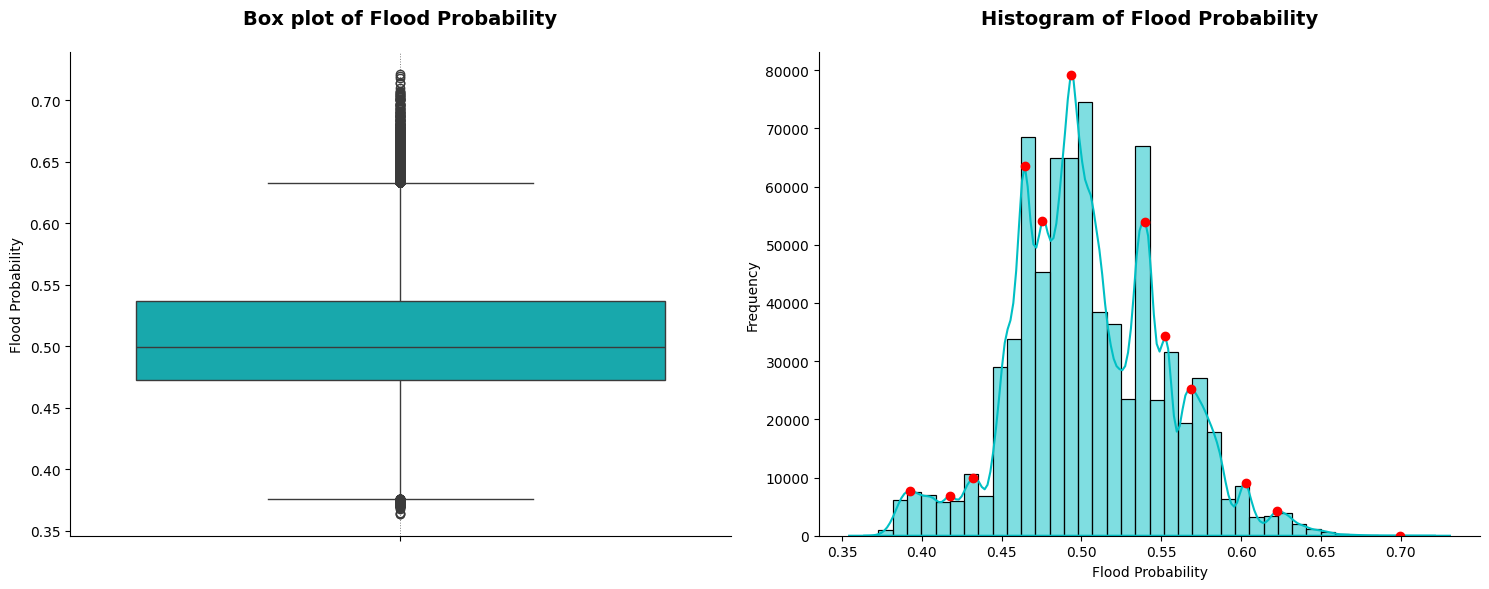

In [41]:
fig, ax = plt.subplots(nrows=1, ncols=2, sharey=False, figsize=(15, 6))

sns.boxplot(data=submission_df, y = "FloodProbability", ax=ax[0], color="#00BFC4")
ax[0].set_title(f"Box plot of Flood Probability", fontsize=14, pad=20, weight="bold")
ax[0].grid(axis="x", color="gray", linestyle=":", linewidth=0.7)
ax[0].set_ylabel("Flood Probability")
sns.despine(ax=ax[0], top=True, right=True, left=False, bottom=False)

sns.histplot(data=submission_df, x = "FloodProbability", ax=ax[1], color="#00BFC4", kde=True, bins=40)
ax[1].set_title(f"Histogram of Flood Probability", fontsize=14, pad=20, weight="bold")
ax[1].set_xlabel("Flood Probability")
ax[1].set_ylabel("Frequency")
sns.despine(ax=ax[1], top=True, right=True, left=False, bottom=False)

# Extract KDE values to find peaks
kde = sns.kdeplot(submission_df["FloodProbability"], ax=ax[1], color="#00BFC4").lines[0].get_data()
kde_x, kde_y = kde[0], kde[1]
peaks, _ = find_peaks(kde_y)

# Highlight peaks
for peak_idx in peaks:
    plt.plot(kde_x[peak_idx], kde_y[peak_idx], "ro")  # Red dots on peaks

plt.tight_layout()
plt.show()

**Target Variable: Flood Probability**

**Box Plot (Left)**

* The **median** is around **0.50**, indicating a balanced central tendency of flood probability.
* The **IQR (Interquartile Range)** spans approximately from **0.47 to 0.54**, showing that most observations fall within this stable mid-range zone.
* There are a few **outliers** below **0.38** and above **0.65**, suggesting rare regions with unusually low or high flood probabilities.
* The spread appears **moderate and symmetric**, implying consistent distribution without strong skewness.

**Histogram (Right)**

* The distribution is **slightly right-skewed**, indicating that lower probabilities occur slightly more frequently.
* The **mode** is around **0.48–0.50**, which aligns well with the median from the box plot.
* The frequency gradually decreases beyond **0.55**, reflecting fewer high-risk flood cases.
* There are small secondary peaks around **0.6**, possibly representing clusters of regions with elevated flood risks.

**Overall Conclusion**

* Most samples have flood probabilities between **0.45 and 0.55**, representing **moderate flood risk**.
* The presence of **high-end outliers (>0.65)** highlights **localized extreme conditions** worth further analysis.
* Overall, the target variable is **stable and near-symmetric**, making it suitable for regression modeling without transformation.

PermutationExplainer explainer: 1001it [03:09,  5.20it/s]                          


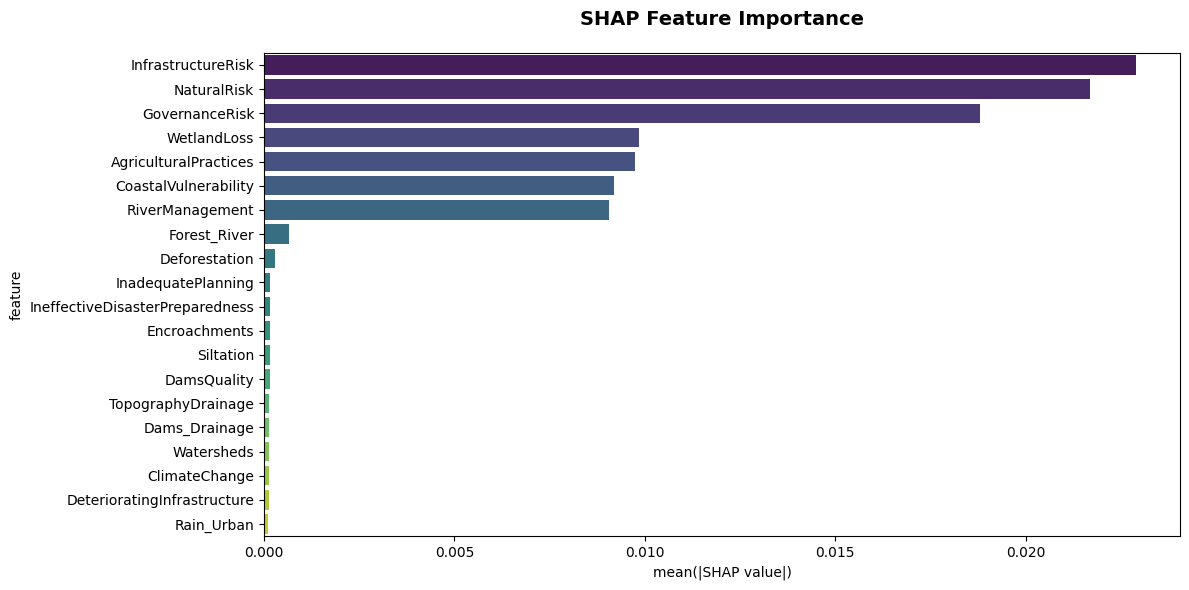

In [42]:
shap_plot(model=model_cb, X_test=df_test_prepared[:1000],
          list_feature=clean_features_2, type="bar")

**SHAP Feature Importance Analysis**

**Top Influential Features**

* **InfrastructureRisk**, **NaturalRisk**, and **GovernanceRisk** are the **most influential factors**, indicating their central role in determining flood probability.
* These variables capture the combined effects of **infrastructure quality, natural hazards, and governance capacity**, highlighting that **structural and environmental factors are the dominant drivers** of flood risk.

**Moderately Important Features**

* **WetlandLoss**, **AgriculturalPractices**, **CoastalVulnerability**, and **RiverManagement** also contribute significantly, showing that **ecological and land-use factors** are strongly linked to flood likelihood.

**Low-Impact Features**

* Features such as **IneffectiveDisasterPreparedness**, **Encroachments**, and **DamsQuality** have relatively low SHAP values, suggesting **limited or indirect influence** on the model’s predictions.

**Overall Insight**
→ The CatBoost model places strong emphasis on **environmental and infrastructure-related features**, indicating that these are the **primary determinants of Flood Probability**, while management and planning variables provide **secondary but supportive contributions**.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Recommendation</span>

<div style="
    border-radius: 15px;
    border: 2px solid #003366;
    padding: 10px;
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff);
    text-align: center;
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF;
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7);
        font-weight: bold;
        margin-bottom: 5px;
        font-size: 28px;
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Recommendation
    </h1>
</div>


**1. Prioritize Infrastructure Resilience**
→ Since **InfrastructureRisk** is the strongest driver, investment should focus on **modernizing flood-control infrastructure**, improving drainage systems, and maintaining critical facilities (e.g., dams, levees, roads).
*This directly reduces exposure in high-risk zones.*

**2. Strengthen Natural and Environmental Defenses**
→ High SHAP values for **NaturalRisk** and **WetlandLoss** highlight the importance of **preserving natural buffers** such as wetlands and riverbanks.
*Implement reforestation and wetland restoration programs to enhance natural flood absorption capacity.*

**3. Enhance Governance and Planning Capacity**
→ **GovernanceRisk** significantly influences flood probability, implying that **effective local planning and regulatory enforcement** can reduce vulnerability.
*Encourage transparent flood zoning, stricter land-use regulations, and improved coordination among agencies.*

**4. Promote Sustainable Agricultural and Coastal Management**
→ Moderate importance of **AgriculturalPractices** and **CoastalVulnerability** suggests that **unsustainable land use** and **coastal degradation** contribute to flood exposure.
*Adopt climate-smart agriculture and reinforce coastal defenses.*

**5. Improve Early-Warning and Preparedness Systems**
→ Although **IneffectiveDisasterPreparedness** and **Encroachments** have lower SHAP impact, they remain actionable levers.
*Enhancing community-based awareness and emergency response planning can mitigate losses even in high-risk areas.*

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

<div style="
    border-radius: 15px;
    border: 2px solid #003366;
    padding: 10px;
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff);
    text-align: center;
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF;
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7);
        font-weight: bold;
        margin-bottom: 5px;
        font-size: 28px;
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        🙏 Thanks for Reading! 🚀
    </h1>
    <p style="color: #ffffff; font-size: 18px; text-align: center;">
        Happy Coding! 🙌😊
    </p>
</div>
